# ДЗ №2. Первая модель — учимся оценивать качество торговой стратегии

**Студент**: Сизиков Константин

**Цель**:
Студент научится строить конвейер тестирования торговой стратегии.
Результат - конвейер оценки качества торговой стратегии, готовый для дальнейшего использования при построении моделей.


**Описание/Пошаговая инструкция выполнения домашнего задания**:
Создать код на Python, который разделит ваши данные на тренировочный, тестовый и валидационный наборы данных.
Построить одну или несколько моделей на основе классификации, которая будет принимать торговые решения по бумагам SnP500 и/или криптовалютам.
Построить конвейер обратного тестирования полученной стратегии.
Провести подбор гиперпараметров моделей с использованием обучающей и тестовой выборок.
Провести финальное тестирование построенных торговых стратегий на валидационном наборе данных и сравнить их между собой.
Сформировать дашборд, показывающий эффективность различных стратегий во времени.



In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from catboost import CatBoostClassifier

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
PERIODS_PER_YEAR = 24 * 365
FEE_RATE = 0.001
N_CV_SPLITS = 5
N_TRIALS = 30
N_LAGS = 24
EMBARGO = 1
OPTUNA_METRIC = "roc_auc"

DATA_PATH = "data/btc_1h.csv"

np.random.seed(RANDOM_STATE)
plt.rcParams["figure.dpi"] = 110

# Метрики классификации
CLS_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]

# Метрики торговой стратегии
TRADE_COLS = ["gross_return", "fee_drag", "total_return", "sharpe", "max_drawdown", "n_trades"]
REPORT_COLS = CLS_COLS + TRADE_COLS

COLORS = {
    "BuyAndHold": "#44403c",
    "LogisticRegression": "#2a78d6",
    "DecisionTree": "#eb6834",
    "CatBoost": "#1baf7a",
}
STYLES = {"BuyAndHold": (0, (5, 2))}
SHORT = {"BuyAndHold": "B&H", "LogisticRegression": "LogReg",
         "DecisionTree": "Tree", "CatBoost": "CatBoost"}
INK, INK_MUTED, GRID = "#1c1917", "#57534e", "#e7e5e4"


## 1. Загрузка данных

Часовые бары BTC/USDT.

In [2]:
raw = pd.read_csv(DATA_PATH)

# Приводим схему файла к единому контракту date + OHLCV.
COLUMN_MAP = {"datetime": "date", "date": "date", "open": "open", "high": "high",
              "low": "low", "close": "close", "volume": "volume"}
raw = raw.rename(columns={c: COLUMN_MAP[c.lower()] for c in raw.columns if c.lower() in COLUMN_MAP})
assert not raw.columns.duplicated().any(), f"После переименования появились дубли колонок: {list(raw.columns)}"

OHLCV = ["open", "high", "low", "close", "volume"]
absent = [c for c in ["date"] + OHLCV if c not in raw.columns]
assert not absent, f"В {DATA_PATH} нет обязательных колонок {absent}; фактически есть: {list(raw.columns)}"

# utc=True + tz_convert(None) -> натживный UTC независимо от того, была таймзона в файле или нет
raw["date"] = pd.to_datetime(raw["date"], utc=True).dt.tz_convert(None)

# Проверка целостности данных
n_before = len(raw)
dup_rows = raw.duplicated(subset="date", keep=False).sum()
conflicting = 0
if dup_rows:
    g = raw[raw.duplicated(subset="date", keep=False)].groupby("date").nunique()
    conflicting = int((g[OHLCV] > 1).any(axis=1).sum())

raw = raw.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)

full_grid = pd.date_range(raw["date"].min(), raw["date"].max(), freq="h")
missing = full_grid.difference(raw["date"])

print(f"Загружено строк: {n_before}")
print(f"  строк с дублирующимися метками времени: {dup_rows} "
      f"(из них с РАСХОЖДЕНИЕМ в OHLCV: {conflicting}) -> удалено {n_before - len(raw)}")
print(f"  пропущенных часов в сетке: {len(missing)}")
assert conflicting == 0, "Дубликаты timestamp содержат разные котировки — нужно решить, какую строку оставить"
assert len(missing) == 0, f"В ряду есть пропуски ({len(missing)} часов) — лаговые признаки будут смещены во времени"
print(f"OK: непрерывный часовой ряд, {len(raw)} баров, "
      f"период {raw['date'].min()} — {raw['date'].max()}")

raw = raw[["date"] + OHLCV]
raw.head()


Загружено строк: 48625
  строк с дублирующимися метками времени: 0 (из них с РАСХОЖДЕНИЕМ в OHLCV: 0) -> удалено 0
  пропущенных часов в сетке: 0
OK: непрерывный часовой ряд, 48625 баров, период 2021-01-01 00:00:00 — 2026-07-20 00:00:00


,date,open,high,low,close,volume
0,2021-01-01 00:00:00,28921.5,29026.0,28703.5,28990.0,917.494
1,2021-01-01 01:00:00,28990.0,29505.5,28956.5,29411.0,1927.830
2,2021-01-01 02:00:00,29411.0,29462.0,29150.0,29218.0,931.537
3,2021-01-01 03:00:00,29218.0,29358.5,29171.5,29303.0,440.535
4,2021-01-01 04:00:00,29303.0,29397.5,29078.0,29229.5,711.549


## 1.1 Визуализация

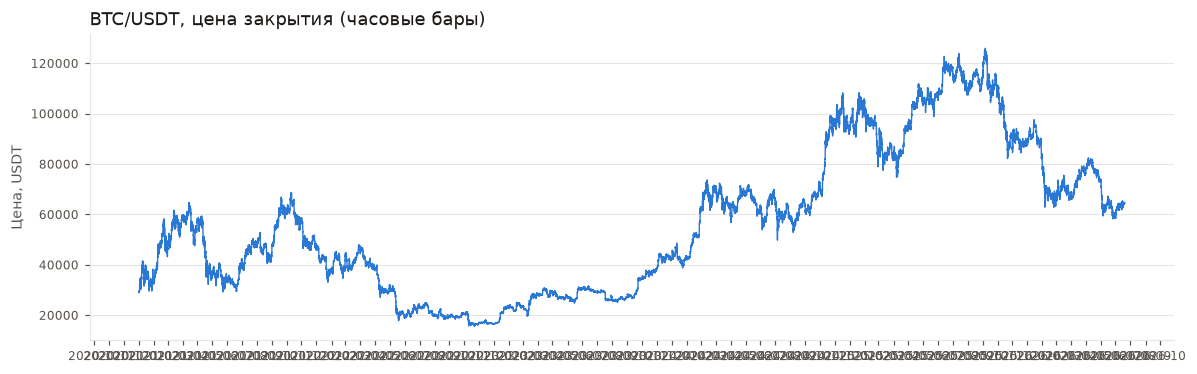

In [3]:
# Цены закрытия BTC/USDT за весь период
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(raw["date"], raw["close"], color=COLORS["LogisticRegression"], linewidth=0.9)
ax.set_title("BTC/USDT, цена закрытия (часовые бары)", color=INK, loc="left")
ax.set_ylabel("Цена, USDT", color=INK_MUTED, fontsize=9)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.grid(axis="y", color=GRID, linewidth=0.7)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK_MUTED, labelsize=8)
fig.tight_layout()
plt.show()


## 2. Признаки: только лаги доходности

Используем только лаги без индикаторов технического анализа

Признак `ret_lag_k` — часовая доходность закрытия, сдвинутая на `k` часов назад: `ret_lag_0` —
последняя известная в момент `t` часовая доходность (от `t-1` до `t`), `ret_lag_1` — доходность
часом раньше, и так далее до `ret_lag_{N_LAGS-1}`. Число лагов задаётся параметром `N_LAGS` в
начальной ячейке.

**Целевая переменная** `target` — направление следующего бара (1 — рост, 0 — падение). Модель делает
прогноз, используя только информацию, доступную к моменту `t`, и таргет соответствует движению цены
на интервале `t -> t+1`, что исключает заглядывание в будущее (look-ahead bias).


In [4]:
# Строки с NaN (первые N_LAGS баров и последний бар) отбрасываются.
def build_features(raw_df, n_lags=N_LAGS):
    d = raw_df.copy()
    close = d["close"]
    ret = close.pct_change(1)

    for lag in range(n_lags):
        d[f"ret_lag_{lag}"] = ret.shift(lag)

    # Таргет и форвардная доходность: прогноз в момент t относится к движению цены (t -> t+1)
    d["target"] = (close.shift(-1) > close).astype(int)
    d["fwd_ret"] = close.shift(-1) / close - 1

    return d


feat = build_features(raw)
non_feature_cols = {"date", "open", "high", "low", "close", "volume", "turnover", "target", "fwd_ret"}
feature_cols = [c for c in feat.columns if c not in non_feature_cols]

feat = feat.dropna(subset=feature_cols + ["target", "fwd_ret"]).reset_index(drop=True)

print(f"Признаков (лагов доходности): {len(feature_cols)}, наблюдений после удаления NaN: {len(feat)}")
print("Баланс классов:", feat["target"].value_counts(normalize=True).round(3).to_dict())
feat[feature_cols].describe().T.head(10)


Признаков (лагов доходности): 24, наблюдений после удаления NaN: 48600
Баланс классов: {1: 0.504, 0: 0.496}


,count,mean,std,min,25%,50%,75%,max
ret_lag_0,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_1,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_2,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_3,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_4,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_5,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_6,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_7,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_8,48600.0,0.000036,0.006255,-0.092797,-0.002286,0.000033,0.002412,0.125
ret_lag_9,48600.0,0.000036,0.006255,-0.092797,-0.002287,0.000033,0.002412,0.125


## 3. Разбиваем на train / test / validation

Данные — временной ряд, поэтому разбиение делается **без перемешивания**, строго по времени:

- **train** (70%) — обучение моделей;
- **test** (15%) — используется совместно с train для подбора гиперпараметров (Optuna);
- **validation** (15%) — полностью отложенная выборка для финального сравнения стратегий.

`dev` = train + test — набор, внутри которого проводится кросс-валидация временных рядов при подборе
гиперпараметров. Validation используется только один раз, в самом конце.

In [5]:
n = len(feat)
train_end = int(n * 0.70)
test_end = int(n * 0.85)

# последний бар обучающей части выбрасывается, чтобы его метка (t -> t+1)
# не перекрывалась с периодом наблюдения следующей выборки
train_df = feat.iloc[:train_end - EMBARGO].reset_index(drop=True)
test_df = feat.iloc[train_end:test_end - EMBARGO].reset_index(drop=True)
val_df = feat.iloc[test_end:].reset_index(drop=True)
dev_df = feat.iloc[:test_end - EMBARGO].reset_index(drop=True)   # train + test для CV-подбора

for name, part in (("train", train_df), ("test", test_df), ("validation", val_df)):
    print(f"{name:11s}: {len(part):5d} строк | {part['date'].min()} — {part['date'].max()}")

# контроль: периоды наблюдения выборок не пересекаются даже с учётом метки (t -> t+1)
gap_tr_te = (test_df["date"].min() - train_df["date"].max()) / pd.Timedelta(hours=1)
gap_te_val = (val_df["date"].min() - test_df["date"].max()) / pd.Timedelta(hours=1)
print(f"\nразрыв train->test: {gap_tr_te:.0f} ч, test->validation: {gap_te_val:.0f} ч "
      f"(нужно > 1 ч, т.к. метка занимает 1 бар вперёд)")
assert gap_tr_te > 1 and gap_te_val > 1, "выборки перекрываются по периоду метки"


train      : 34019 строк | 2021-01-02 00:00:00 — 2024-11-19 10:00:00
test       :  7289 строк | 2024-11-19 12:00:00 — 2025-09-19 04:00:00
validation :  7290 строк | 2025-09-19 06:00:00 — 2026-07-19 23:00:00

разрыв train->test: 2 ч, test->validation: 2 ч (нужно > 1 ч, т.к. метка занимает 1 бар вперёд)


## 4. Backtest

Стратегия всегда находится в рынке: позиция `+1` (long), если модель прогнозирует рост следующего
бара, и `-1` (short) в противном случае. Комиссия начисляется пропорционально изменению позиции:
переворот `long -> short` даёт оборот 2 единицы, то есть стоит `2 * FEE_RATE`.

Функция `backtest` возвращает кривую капитала (equity curve), просадку (drawdown) и метрики.
Доходность считается и без издержек (gross), и с издержками (net). Без такого разделения
невозможно отличить две принципиально разные ситуации:

- у модели **нет предсказательной силы** (gross ≈ 0 или отрицателен), и
- у модели **есть edge, но его съедают издержки** (gross > 0, net < 0).

Это различие определяет, что делать дальше: искать другие признаки или снижать оборот. Поэтому
`gross_return` и `fee_drag` — обязательные поля отчёта, а не диагностика «на всякий случай».


In [6]:
def backtest(dates, fwd_ret, signal, fee_rate=FEE_RATE):
    """signal (0/1) принимается в момент t по информации, известной к t; применяется к forward
    return на интервале (t -> t+1). position = +1 (long), если signal == 1, иначе -1 (short).

    Возвращает (curve, metrics). Доходность считается и gross (без издержек), и net (с издержками),
    чтобы отличать отсутствие предсказательной силы от съеденного издержками edge.
    """
    dates = pd.Series(dates).reset_index(drop=True)
    fwd_ret = np.asarray(fwd_ret, dtype=float)
    position = np.where(np.asarray(signal) == 1, 1.0, -1.0)

    prev_position = np.roll(position, 1)
    prev_position[0] = 0.0                      # до первой сделки капитал вне рынка
    turnover = np.abs(position - prev_position)  # переворот long<->short = 2 единицы оборота

    gross_ret = position * fwd_ret
    fees = fee_rate * turnover
    strat_ret = gross_ret - fees

    equity = (1 + strat_ret).cumprod()
    equity_gross = (1 + gross_ret).cumprod()
    running_max = np.maximum.accumulate(equity)
    drawdown = equity / running_max - 1

    n_periods = len(strat_ret)
    if n_periods == 0:
        raise ValueError("backtest получил пустую выборку")

    total_return = float(equity[-1] - 1)
    gross_return = float(equity_gross[-1] - 1)
    ann_factor = PERIODS_PER_YEAR / n_periods
    ann_return = float((1 + total_return) ** ann_factor - 1)
    vol = strat_ret.std(ddof=0)
    sharpe = float((strat_ret.mean() / vol) * np.sqrt(PERIODS_PER_YEAR)) if vol > 0 else 0.0

    curve = pd.DataFrame({
        "date": dates,
        "position": position,
        "strategy_return": strat_ret,
        "equity": equity,
        "equity_gross": equity_gross,
        "drawdown": drawdown,
    })
    metrics = {
        "total_return": total_return,            # net, с издержками
        "gross_return": gross_return,            # без издержек — это и есть "edge" модели
        "fee_drag": float(fees.sum()),           # суммарные издержки в долях капитала
        "annualized_return": ann_return,
        "sharpe": sharpe,
        "max_drawdown": float(drawdown.min()),
        "n_trades": int((turnover > 0).sum()),   # включая первый вход в позицию
        "turnover_units": float(turnover.sum()),
        "profitable_bars": float((strat_ret > 0).mean()),  # доля прибыльных БАРОВ (не сделок)
    }
    return curve, metrics

Buy & Hold (train):
  total_return      : 2.1383
  gross_return      : 2.1414
  fee_drag          : 0.0010
  annualized_return : 0.3425
  sharpe            : 0.7819
  max_drawdown      : -0.7723
  n_trades          : 1
  turnover_units    : 1.0000
  profitable_bars   : 0.5057
  контроль: изменение цены за период = 2.1414, gross_return = 2.1414

Идеальный прогноз (oracle, sanity check знака сигнала): gross=15275452567044341126272933045163729648596297465875994079395840.00, sharpe=53.1


## 4.5. Метрики качества классификации и выбор метрики для Optuna

Для Optuna выбираем ROC-AUC, как устойчивую в вырождению модели.

Кроме экономических метрик стратегии считаем шесть стандартных метрик классификации:
 - accuracy
 - precision
 - recall
 - F1
 - ROC-AUC
 - PR-AUC




In [7]:
def predict_labels(model, X):
    """Метки класса (0/1) в виде плоского int-массива — единый формат для всех моделей."""
    return np.asarray(model.predict(X)).astype(int).ravel()


def predict_proba1(model, X):
    """Вероятность класса 1 (рост). Нужна для порогонезависимых ROC-AUC и PR-AUC."""
    return np.asarray(model.predict_proba(X))[:, 1]


def classification_metrics(y_true, y_pred, y_proba):
    """Шесть метрик качества классификатора.

    accuracy/precision/recall/f1 считаются по меткам и зависят от порога 0.5;
    roc_auc/pr_auc считаются по вероятностям и от порога не зависят.
    zero_division=0 — чтобы вырожденный прогноз «всегда падение» давал 0, а не ошибку.
    """
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }


Доля класса 1 (рост) в train: 0.5057



,accuracy,precision,recall,f1,roc_auc,pr_auc
прогноз,,,,,,
всегда рост (константа),0.5057,0.5057,1.0000,0.6717,0.5,0.5057
всегда падение (константа),0.4943,0.0000,0.0000,0.0000,0.5,0.5057
случайный,0.5004,0.5060,0.5029,0.5044,0.5,0.5047


Вывод: recall и F1 максимальны у прогноза-константы «всегда рост» — оптимизировать их нельзя.
ROC-AUC у обеих константных стратегий = 0.5 -> метрика честно фиксирует отсутствие модели.
Поэтому OPTUNA_METRIC = 'roc_auc'.


## 5. Базовые модели (без подбора гиперпараметров)

Обучаем логистическую регрессию, дерево решений и CatBoost с параметрами по умолчанию на `train`,
и сразу прогоняем полученные торговые решения через backtest на `test`, чтобы убедиться, что весь
конвейер работает корректно, прежде чем переходить к подбору гиперпараметров.


In [8]:
X_train, y_train = train_df[feature_cols], train_df["target"]
X_test, y_test = test_df[feature_cols], test_df["target"]

def make_logreg(**params):
    return Pipeline([
        # scaler внутри Pipeline: при CV он обучается только на train-части фолда,
        # поэтому статистики масштабирования не подсматриваются из теста
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **params)),
    ])

def make_tree(**params):
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)

def make_catboost(**params):
    return CatBoostClassifier(verbose=False, random_state=RANDOM_STATE, allow_writing_files=False, **params)


baseline_models = {
    "LogisticRegression": make_logreg(),
    "DecisionTree": make_tree(max_depth=5),
    "CatBoost": make_catboost(iterations=200, depth=4, learning_rate=0.05),
}

baseline_rows = []
for name, model in baseline_models.items():
    model.fit(X_train, y_train)
    pred = predict_labels(model, X_test)
    prob = predict_proba1(model, X_test)
    cls = classification_metrics(y_test, pred, prob)
    _, trade = backtest(test_df["date"], test_df["fwd_ret"], pred)
    baseline_rows.append({"model": name, **cls, **trade})

baseline_report = pd.DataFrame(baseline_rows).set_index("model")
print("Метрики классификации (test):")
display(baseline_report[CLS_COLS].round(4))
print("Метрики торговой стратегии (test):")
display(baseline_report[TRADE_COLS].round(4))


Метрики классификации (test):


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
LogisticRegression,0.5267,0.5260,0.6372,0.5763,0.5389,0.5409
DecisionTree,0.5196,0.5201,0.6339,0.5714,0.5280,0.5294
CatBoost,0.5311,0.5348,0.5516,0.5430,0.5384,0.5385


Метрики торговой стратегии (test):


,gross_return,fee_drag,total_return,sharpe,max_drawdown,n_trades
model,,,,,,
LogisticRegression,1.1319,4.887,-0.9840,-10.4372,-0.9844,2444
DecisionTree,0.2401,5.503,-0.9950,-13.3276,-0.9951,2752
CatBoost,1.8681,5.207,-0.9844,-10.4637,-0.9847,2604


## 6. Подбор гиперпараметров: Optuna + кросс-валидация временных рядов

> Кросс-валидация временных рядов: данные разбиваются на k частей (fold). Обучение модели
> производится на частях, предшествующих тестированию. Процедура повторяется k раз, так что каждая
> из k частей используется для тестирования. Итог — оценка эффективности модели с наиболее
> равномерным использованием имеющихся данных.

Используем `sklearn.model_selection.TimeSeriesSplit` (expanding window) на
`dev`-наборе (train + test), то есть подбор гиперпараметров идёт с использованием обучающей и
тестовой выборок, как и требуется в задании. Валидационная выборка в этом процессе не участвует.

**Целевая метрика Optuna — ROC-AUC** (`OPTUNA_METRIC`), усреднённый по фолдам.

Вместе с целевой метрикой на каждом фолде считаются и остальные метрики, включая Sharpe стратегии.
Они сохраняются в `trial.set_user_attr(...)`.


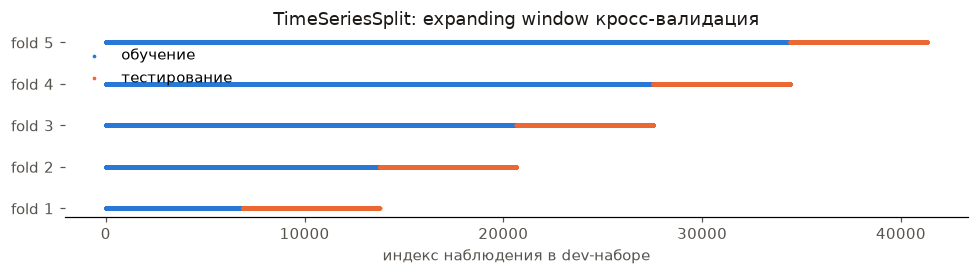

In [9]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=EMBARGO)   # gap — тот же purging, что и при нарезке выборок

X_dev = dev_df[feature_cols].reset_index(drop=True)
y_dev = dev_df["target"].reset_index(drop=True)
fwd_dev = dev_df["fwd_ret"].reset_index(drop=True)
dates_dev = dev_df["date"].reset_index(drop=True)

# Визуализация схемы разбиения (expanding window)
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_dev)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c="#2a78d6", s=2, label="обучение" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c="#eb6834", s=2, label="тестирование" if i == 0 else None)
ax.set_yticks(range(N_CV_SPLITS))
ax.set_yticklabels([f"fold {i + 1}" for i in range(N_CV_SPLITS)])
ax.set_xlabel("индекс наблюдения в dev-наборе", color=INK_MUTED)
ax.set_title("TimeSeriesSplit: expanding window кросс-валидация", color=INK)
ax.legend(loc="upper left", frameon=False)
ax.tick_params(colors=INK_MUTED)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()


def cv_evaluate(build_model_fn):
    """Средние по k фолдам метрики: шесть метрик классификации + Sharpe и оборот стратегии.

    Возвращает один dict. Optuna берёт из него OPTUNA_METRIC, остальное пишется
    в user_attrs, чтобы затем сравнить статистическое качество с экономикой.
    """
    rows = []
    for tr_idx, te_idx in tscv.split(X_dev):
        model = build_model_fn()
        model.fit(X_dev.iloc[tr_idx], y_dev.iloc[tr_idx])
        pred = predict_labels(model, X_dev.iloc[te_idx])
        prob = predict_proba1(model, X_dev.iloc[te_idx])
        m = classification_metrics(y_dev.iloc[te_idx], pred, prob)
        _, trade = backtest(dates_dev.iloc[te_idx], fwd_dev.iloc[te_idx], pred)
        m["sharpe"] = trade["sharpe"]
        m["total_return"] = trade["total_return"]
        m["n_trades"] = trade["n_trades"]
        rows.append(m)
    return pd.DataFrame(rows).mean().to_dict()


def run_study(objective, name):
    """Запускает Optuna-исследование и печатает целевую метрику вместе с экономикой."""
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    a = study.best_trial.user_attrs
    print(f"{name}: лучший CV {OPTUNA_METRIC} = {study.best_value:.4f}")
    print(f"  гиперпараметры: {study.best_params}")
    print(f"  на тех же фолдах: accuracy={a['accuracy']:.4f}, F1={a['f1']:.4f}, "
          f"PR-AUC={a['pr_auc']:.4f} | Sharpe={a['sharpe']:.2f}, сделок={a['n_trades']:.0f}")
    return study


In [10]:
# Подбор гиперпараметров для логистической регрессии.
# Optuna перебирает силу регуляризации C и тип штрафа (l1/l2), подбирая solver
# под штраф. Максимизируется CV ROC-AUC; остальные метрики (включая Sharpe)
# сохраняются в user_attrs той же попытки.
def objective_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
    }
    params["solver"] = "saga" if params["penalty"] == "l1" else "lbfgs"
    scores = cv_evaluate(lambda: make_logreg(**params))
    for k, v in scores.items():
        trial.set_user_attr(k, float(v))
    return scores[OPTUNA_METRIC]


study_logreg = run_study(objective_logreg, "LogisticRegression")


LogisticRegression: лучший CV roc_auc = 0.5456
  гиперпараметры: {'C': 0.0060855454958555445, 'penalty': 'l1'}
  на тех же фолдах: accuracy=0.5261, F1=0.6102, PR-AUC=0.5419 | Sharpe=-7.90, сделок=1580


In [11]:
# Подбор гиперпараметров для дерева решений.
# Перебираются глубина, минимальные размеры разбиения и листа (контроль
# переобучения) и критерий расщепления. Метрика — та же, CV ROC-AUC.
def objective_tree(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 2, 12),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 60),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    scores = cv_evaluate(lambda: make_tree(**params))
    for k, v in scores.items():
        trial.set_user_attr(k, float(v))
    return scores[OPTUNA_METRIC]


study_tree = run_study(objective_tree, "DecisionTree")


DecisionTree: лучший CV roc_auc = 0.5392
  гиперпараметры: {'max_depth': 4, 'min_samples_split': 42, 'min_samples_leaf': 10, 'criterion': 'entropy'}
  на тех же фолдах: accuracy=0.5297, F1=0.5321, PR-AUC=0.5318 | Sharpe=-12.59, сделок=2682


In [12]:
# Подбор гиперпараметров для градиентного бустинга (catboost).
# Перебираются глубина деревьев, темп обучения, L2-регуляризация и число
# итераций. Метрика — та же, CV ROC-AUC, поэтому все три модели сравниваются
# в одинаковых условиях: одни данные, одни фолды, одна целевая метрика.
def objective_catboost(trial):
    params = {
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        "iterations": trial.suggest_int("iterations", 100, 400),
    }
    scores = cv_evaluate(lambda: make_catboost(**params))
    for k, v in scores.items():
        trial.set_user_attr(k, float(v))
    return scores[OPTUNA_METRIC]


study_catboost = run_study(objective_catboost, "CatBoost")


CatBoost: лучший CV roc_auc = 0.5505
  гиперпараметры: {'depth': 3, 'learning_rate': 0.013913051689665964, 'l2_leaf_reg': 8.146909399942116, 'iterations': 340}
  на тех же фолдах: accuracy=0.5355, F1=0.5409, PR-AUC=0.5467 | Sharpe=-11.14, сделок=2416


In [13]:
# Сравнение результатов подбора гиперпараметров.
studies = {"LogisticRegression": study_logreg, "DecisionTree": study_tree, "CatBoost": study_catboost}

tuning_summary = pd.DataFrame([
    {
        "model": name,
        f"CV {OPTUNA_METRIC}": st.best_value,
        "CV accuracy": st.best_trial.user_attrs["accuracy"],
        "CV f1": st.best_trial.user_attrs["f1"],
        "CV pr_auc": st.best_trial.user_attrs["pr_auc"],
        "CV sharpe": st.best_trial.user_attrs["sharpe"],
        "CV n_trades": st.best_trial.user_attrs["n_trades"],
        "best_params": st.best_params,
    }
    for name, st in studies.items()
]).set_index("model")

display(tuning_summary.drop(columns="best_params").round(4))
for name, st in studies.items():
    print(f"{name}: {st.best_params}")


,CV roc_auc,CV accuracy,CV f1,CV pr_auc,CV sharpe,CV n_trades
model,,,,,,
LogisticRegression,0.5456,0.5261,0.6102,0.5419,-7.8990,1580.4
DecisionTree,0.5392,0.5297,0.5321,0.5318,-12.5911,2681.8
CatBoost,0.5505,0.5355,0.5409,0.5467,-11.1354,2416.0


LogisticRegression: {'C': 0.0060855454958555445, 'penalty': 'l1'}
DecisionTree: {'max_depth': 4, 'min_samples_split': 42, 'min_samples_leaf': 10, 'criterion': 'entropy'}
CatBoost: {'depth': 3, 'learning_rate': 0.013913051689665964, 'l2_leaf_reg': 8.146909399942116, 'iterations': 340}


## 7. Финальные модели

Обучаем модели с лучшими гиперпараметрами на всём `dev`-наборе (train + test) — тех же данных, что
использовались при подборе гиперпараметров, — и переходим к единственной проверке на отложенной `validation`-выборке.


In [14]:
# Финальное обучение.
X_dev_full, y_dev_full = dev_df[feature_cols], dev_df["target"]
X_val, y_val = val_df[feature_cols], val_df["target"]

final_params = {
    "LogisticRegression": study_logreg.best_params,
    "DecisionTree": study_tree.best_params,
    "CatBoost": study_catboost.best_params,
}

final_builders = {
    "LogisticRegression": lambda p: make_logreg(**{**p, "solver": "saga" if p["penalty"] == "l1" else "lbfgs"}),
    "DecisionTree": lambda p: make_tree(**p),
    "CatBoost": lambda p: make_catboost(**p),
}

final_models = {}
for name, builder in final_builders.items():
    model = builder(final_params[name])
    model.fit(X_dev_full, y_dev_full)
    final_models[name] = model

print(f"Финальные модели обучены на {len(X_dev_full)} наблюдениях (train + test).\n")

# Проверяем, не вырождается ли модель
degenerate = {}
diag_rows = []
for name, model in final_models.items():
    pred = np.asarray(model.predict(X_val)).astype(int).ravel()
    n_classes = len(np.unique(pred))
    row = {"model": name, "предсказано классов": n_classes, "доля long": round(float(pred.mean()), 4)}
    if name == "LogisticRegression":
        coefs = model.named_steps["clf"].coef_.ravel()
        row["ненулевых коэф."] = f"{int((coefs != 0).sum())} / {len(coefs)}"
    else:
        row["ненулевых коэф."] = "—"
    degenerate[name] = n_classes == 1
    row["вырождена"] = "ДА" if degenerate[name] else "нет"
    diag_rows.append(row)

display(pd.DataFrame(diag_rows).set_index("model"))

for name, is_deg in degenerate.items():
    if is_deg:
        print(f"ВНИМАНИЕ: {name} предсказывает один и тот же класс на всей валидации — "
              f"регуляризация обнулила все признаки, и стратегия тождественна buy & hold, "
              f"а не является самостоятельной моделью.")


Финальные модели обучены на 41309 наблюдениях (train + test).



,предсказано классов,доля long,ненулевых коэф.,вырождена
model,,,,
LogisticRegression,2,0.6894,12 / 24,нет
DecisionTree,2,0.5993,—,нет
CatBoost,2,0.5432,—,нет


## 8. Финальное тестирование на валидационной выборке

Сравниваем три построенные стратегии между собой и с бенчмарком buy & hold на данных, которые не
участвовали ни в обучении моделей, ни в подборе гиперпараметров.


In [15]:
val_curves = {}
val_metrics_rows = []

bh_signal = np.ones(len(val_df), dtype=int)
bh_curve, bh_trade = backtest(val_df["date"], val_df["fwd_ret"], bh_signal)
bh_cls = classification_metrics(y_val, bh_signal, np.full(len(val_df), 0.5))
val_curves["BuyAndHold"] = bh_curve
val_probas = {}
val_metrics_rows.append({"strategy": "BuyAndHold", **bh_cls, **bh_trade})

for name, model in final_models.items():
    pred = predict_labels(model, X_val)
    prob = predict_proba1(model, X_val)
    val_probas[name] = prob
    cls = classification_metrics(y_val, pred, prob)
    curve, trade = backtest(val_df["date"], val_df["fwd_ret"], pred)
    val_curves[name] = curve
    val_metrics_rows.append({"strategy": name, **cls, **trade})

val_comparison = pd.DataFrame(val_metrics_rows).set_index("strategy")

print(f"Валидация: {len(val_df)} часовых баров, {val_df['date'].min()} — {val_df['date'].max()}")
print("\nКачество классификации:")
display(val_comparison[CLS_COLS].round(4))
print("Экономика стратегии:")
display(val_comparison[TRADE_COLS].round(4))

print("Как читать таблицы:")
print("  roc_auc ~ 0.5   — модель не отличает рост от падения (0.5 = случайное угадывание)")
print("  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge")
print("  total_return    — net: то, что реально осталось бы у трейдера")
for name in final_models:
    g, t = val_comparison.loc[name, "gross_return"], val_comparison.loc[name, "total_return"]
    if g > 0 > t:
        print(f"\n  -> {name}: gross {g:+.2%} против net {t:+.2%} — edge ЕСТЬ, но издержки "
              f"({val_comparison.loc[name, 'fee_drag']:.1%}) его полностью съедают.")


Валидация: 7290 часовых баров, 2025-09-19 06:00:00 — 2026-07-19 23:00:00

Качество классификации:


,accuracy,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,,
BuyAndHold,0.4963,0.4963,1.0000,0.6634,0.5000,0.4963
LogisticRegression,0.5196,0.5115,0.7106,0.5949,0.5294,0.5189
DecisionTree,0.5266,0.5191,0.6269,0.5679,0.5369,0.5214
CatBoost,0.5295,0.5237,0.5732,0.5474,0.5371,0.5234


Экономика стратегии:


,gross_return,fee_drag,total_return,sharpe,max_drawdown,n_trades
strategy,,,,,,
BuyAndHold,-0.4467,0.001,-0.4473,-1.3494,-0.5376,1
LogisticRegression,-0.1869,4.259,-0.9886,-11.4298,-0.9886,2130
DecisionTree,0.3089,4.881,-0.9901,-11.8032,-0.9901,2441
CatBoost,0.1590,5.055,-0.9926,-12.5544,-0.9927,2528


Как читать таблицы:
  roc_auc ~ 0.5   — модель не отличает рост от падения (0.5 = случайное угадывание)
  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge
  total_return    — net: то, что реально осталось бы у трейдера

  -> DecisionTree: gross +30.89% против net -99.01% — edge ЕСТЬ, но издержки (488.1%) его полностью съедают.

  -> CatBoost: gross +15.90% против net -99.26% — edge ЕСТЬ, но издержки (505.5%) его полностью съедают.


### Кривые ROC и Precision–Recall на валидации

Кривые показывают качество *ранжирования* вероятностей на всём диапазоне порогов, а не в одной точке
0.5. Диагональ на ROC и горизонтальная линия на PR (уровень доли положительного класса) — это
поведение модели без различающей способности: чем ближе кривая к ним, тем меньше в модели сигнала.


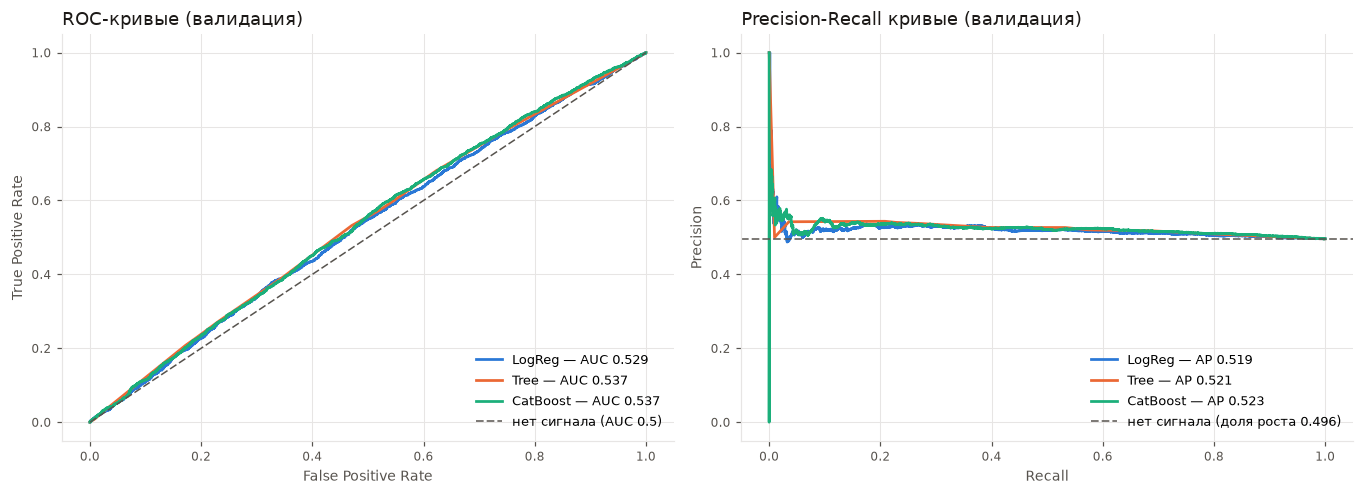

Все три кривые лежат почти на опорных линиях: на часовых лагах доходности предсказательного сигнала практически нет.


In [16]:
prevalence = float(y_val.mean())
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12.5, 4.6))

for name, prob in val_probas.items():
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, color=COLORS[name], linewidth=1.8,
                label=f"{SHORT[name]} — AUC {val_comparison.loc[name, 'roc_auc']:.3f}")
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ax_pr.plot(rec, prec, color=COLORS[name], linewidth=1.8,
               label=f"{SHORT[name]} — AP {val_comparison.loc[name, 'pr_auc']:.3f}")

ax_roc.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
            label="нет сигнала (AUC 0.5)")
ax_roc.set_xlabel("False Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_ylabel("True Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_title("ROC-кривые (валидация)", color=INK, fontsize=11.5, loc="left")

ax_pr.axhline(prevalence, color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
              label=f"нет сигнала (доля роста {prevalence:.3f})")
ax_pr.set_xlabel("Recall", color=INK_MUTED, fontsize=9)
ax_pr.set_ylabel("Precision", color=INK_MUTED, fontsize=9)
ax_pr.set_title("Precision-Recall кривые (валидация)", color=INK, fontsize=11.5, loc="left")

for ax in (ax_roc, ax_pr):
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)

fig.tight_layout()
plt.show()

print("Все три кривые лежат почти на опорных линиях: на часовых лагах доходности "
      "предсказательного сигнала практически нет.")


## 8.5. Чувствительность к издержкам: при какой комиссии стратегия выживает?

Итоговый вывод целиком зависит от `FEE_RATE`, который мы задали равным 0.1% за единицу оборота. Если у
модели положительная gross-доходность, то существует **пороговый уровень издержек (break-even fee)**,
ниже которого стратегия становится прибыльной. Этот порог — куда более информативная характеристика
стратегии, чем net-доходность при одном произвольно выбранном тарифе: он говорит, на какой
инфраструктуре (maker/taker, объём, ребейты) стратегия имела бы смысл.

Для справки: taker-комиссия на BTC-перпетуалах крупных бирж — порядка 0.04–0.055% за сторону,
maker — около 0.01–0.02%, то есть заметно ниже заложенных нами 0.1%.


In [17]:
from scipy.optimize import brentq

val_signals = {"BuyAndHold": np.ones(len(val_df), dtype=int)}
for name, model in final_models.items():
    val_signals[name] = np.asarray(model.predict(X_val)).astype(int).ravel()

FEE_GRID = np.linspace(0.0, 0.0015, 61)
sensitivity = pd.DataFrame(
    {name: [backtest(val_df["date"], val_df["fwd_ret"], sig, fee_rate=f)[1]["total_return"]
            for f in FEE_GRID]
     for name, sig in val_signals.items()},
    index=FEE_GRID,
)

# break-even fee: комиссия, при которой net-доходность обращается в нуль
break_even = {}
for name, sig in val_signals.items():
    f = lambda fee: backtest(val_df["date"], val_df["fwd_ret"], sig, fee_rate=fee)[1]["total_return"]
    if f(0.0) <= 0:
        break_even[name] = np.nan          # нет edge даже при нулевых издержках
    elif f(FEE_GRID[-1]) > 0:
        break_even[name] = np.inf          # прибыльна на всей сетке
    else:
        break_even[name] = brentq(f, 0.0, FEE_GRID[-1])

be = pd.DataFrame({
    "gross_return (fee=0)": [sensitivity[n].iloc[0] for n in val_signals],
    "break_even_fee": [break_even[n] for n in val_signals],
    "текущий FEE_RATE": FEE_RATE,
    "net при FEE_RATE": [val_comparison.loc[n, "total_return"] for n in val_signals],
}, index=list(val_signals)).rename_axis("strategy")
display(be.round(6))

for n, v in break_even.items():
    if np.isnan(v):
        print(f"{n:20s}: edge отсутствует даже при нулевых издержках — проблема не в комиссиях")
    elif np.isinf(v):
        print(f"{n:20s}: прибыльна на всём диапазоне сетки")
    else:
        print(f"{n:20s}: безубыточна при комиссии < {v * 100:.4f}% за единицу оборота "
              f"(в {FEE_RATE / v:.1f} раза ниже заложенных {FEE_RATE * 100:.2f}%)")


,gross_return (fee=0),break_even_fee,текущий FEE_RATE,net при FEE_RATE
strategy,,,,
BuyAndHold,-0.446743,NaN,0.001,-0.447295
LogisticRegression,-0.186881,NaN,0.001,-0.988558
DecisionTree,0.308885,0.000055,0.001,-0.990114
CatBoost,0.158976,0.000029,0.001,-0.992648


BuyAndHold          : edge отсутствует даже при нулевых издержках — проблема не в комиссиях
LogisticRegression  : edge отсутствует даже при нулевых издержках — проблема не в комиссиях
DecisionTree        : безубыточна при комиссии < 0.0055% за единицу оборота (в 18.1 раза ниже заложенных 0.10%)
CatBoost            : безубыточна при комиссии < 0.0029% за единицу оборота (в 34.3 раза ниже заложенных 0.10%)


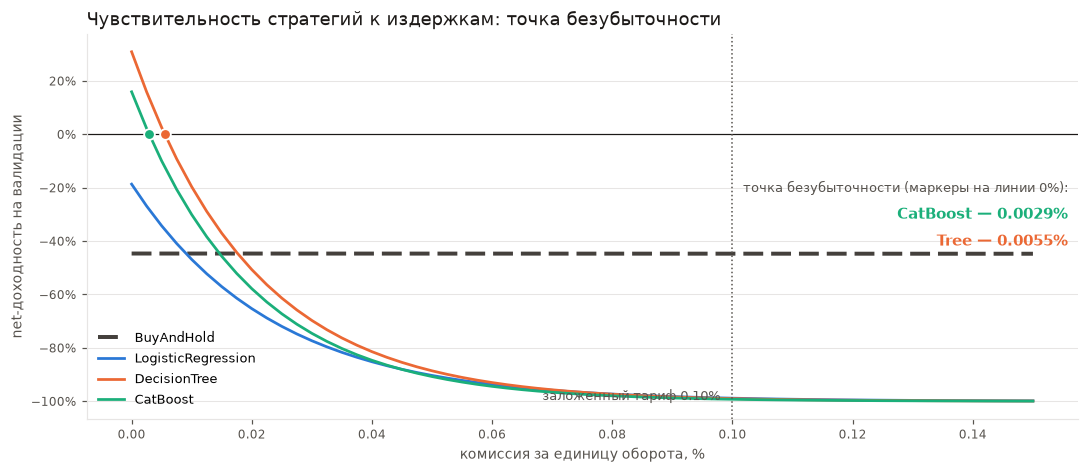

In [18]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for name in sensitivity.columns:
    ax.plot(sensitivity.index * 100, sensitivity[name], color=COLORS[name],
            linewidth=2.6 if name == "BuyAndHold" else 1.8,
            linestyle=STYLES.get(name, "-"), label=name)
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(FEE_RATE * 100, color=INK_MUTED, linewidth=1.0, linestyle=":")
# подпись тарифа — у самой оси X (там пусто), иначе она садится на плоскую линию B&H
ax.annotate(f"заложенный тариф {FEE_RATE * 100:.2f}%",
            xy=(FEE_RATE * 100, 0.04), xycoords=("data", "axes fraction"),
            xytext=(-8, 0), textcoords="offset points",
            ha="right", va="bottom", fontsize=8.5, color=INK_MUTED)

# Точки безубыточности лежат почти вплотную у левого края, поэтому подписи собраны
# в блок в свободной области справа-внизу: поводки от точек в левом углу перечёркивали
# бы весь график, а подписи у самих точек накладывались бы друг на друга.
finite_be = sorted([(n, v) for n, v in break_even.items() if np.isfinite(v) and v > 0],
                   key=lambda t: t[1])
for name, v in finite_be:
    ax.plot([v * 100], [0], marker="o", markersize=7, color=COLORS[name],
            markeredgecolor="white", markeredgewidth=1.2, zorder=5)
ax.text(0.99, 0.60, "точка безубыточности (маркеры на линии 0%):", transform=ax.transAxes,
        ha="right", va="center", fontsize=8.5, color=INK_MUTED)
for k, (name, v) in enumerate(finite_be):
    ax.text(0.99, 0.53 - k * 0.07, f"{SHORT[name]} — {v * 100:.4f}%", transform=ax.transAxes,
            ha="right", va="center", fontsize=9.5, color=COLORS[name], fontweight="bold")

ax.set_xlabel("комиссия за единицу оборота, %", color=INK_MUTED, fontsize=9)
ax.set_ylabel("net-доходность на валидации", color=INK_MUTED, fontsize=9)
ax.set_title("Чувствительность стратегий к издержкам: точка безубыточности",
             color=INK, fontsize=11.5, loc="left")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(frameon=False, fontsize=8.5, loc="lower left")
ax.grid(axis="y", color=GRID, linewidth=0.7)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK_MUTED, labelsize=8)
fig.tight_layout()
plt.show()


## 9. Дашборд эффективности стратегий во времени


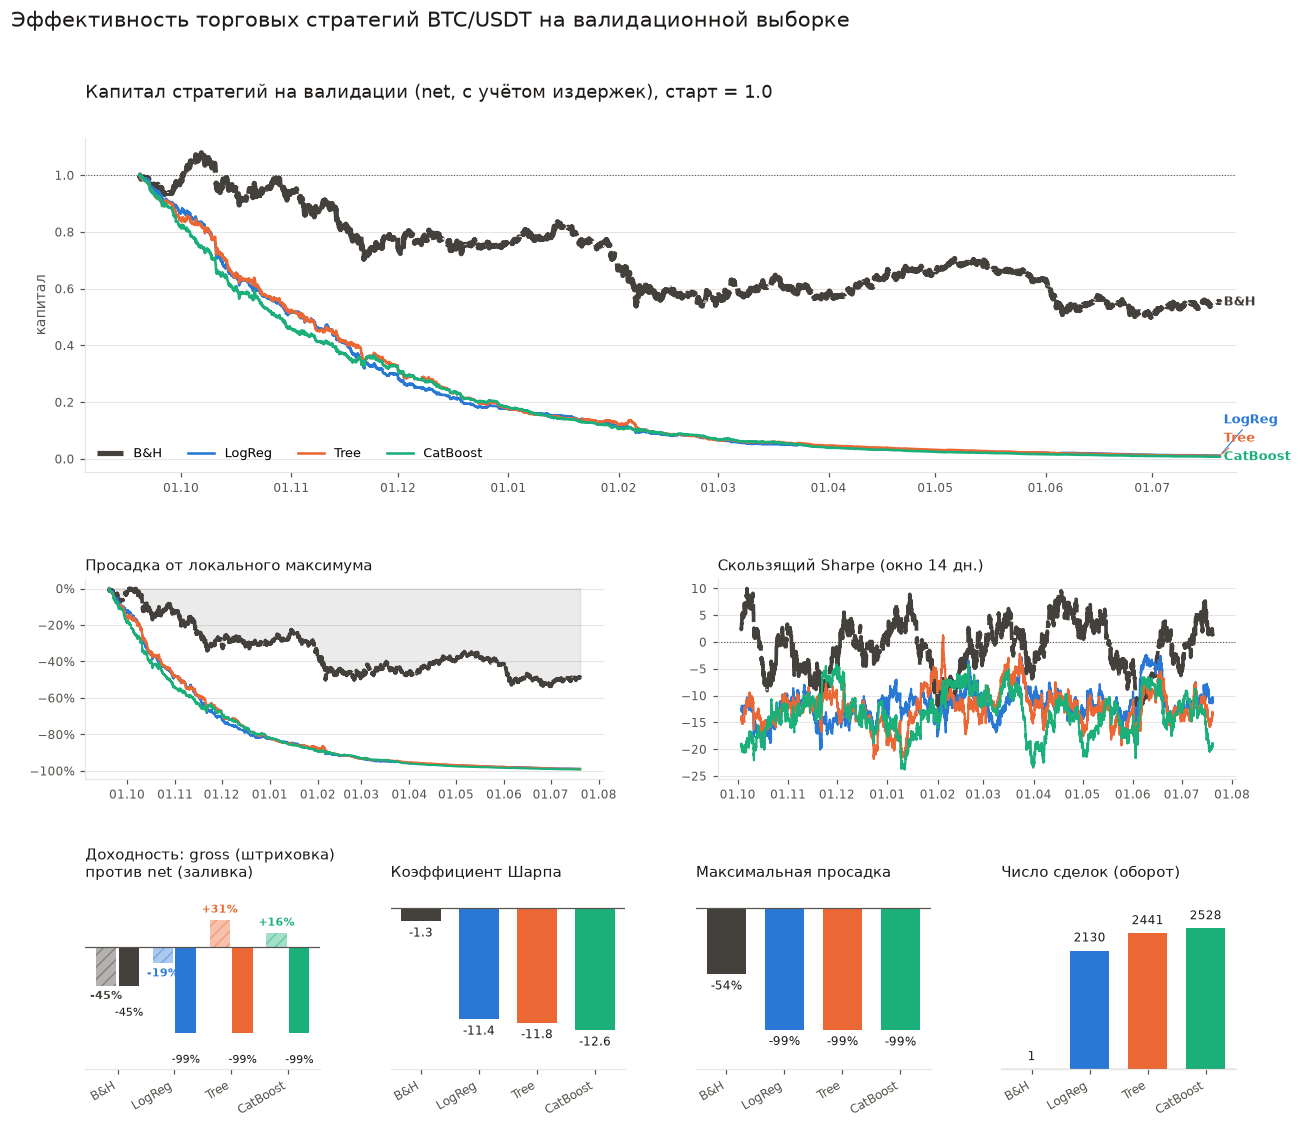

In [19]:
# Четыре блока: кривые капитала, просадка, скользящий Sharpe и сводные метрики.
# Метрики разнесены по отдельным панелям (small multiples), потому что проценты,
# Sharpe и число сделок измеряются в разных единицах и на одной оси несопоставимы.
strategies = list(val_curves)


def style_ax(ax, ygrid=True):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.7)
        ax.set_axisbelow(True)


def declutter(pairs, min_gap):
    """Раздвигает подписи по вертикали, чтобы они не накладывались."""
    out, prev = {}, None
    for name, y in sorted(pairs, key=lambda t: t[1]):
        if prev is not None and y - prev < min_gap:
            y = prev + min_gap
        out[name], prev = y, y
    return out


fig = plt.figure(figsize=(13.5, 11))
gs = fig.add_gridspec(3, 2, height_ratios=[2.1, 1.25, 1.15], hspace=0.45, wspace=0.22)

# ── 1. Кривые капитала (net, с издержками) ────────────────────────────────────────
ax_eq = fig.add_subplot(gs[0, :])
for name in strategies:
    curve = val_curves[name]
    is_bench = name == "BuyAndHold"
    ax_eq.plot(curve["date"], curve["equity"], color=COLORS[name],
               linewidth=3.4 if is_bench else 1.7,
               linestyle=STYLES.get(name, "-"),
               zorder=2 if is_bench else 3,
               label=SHORT[name] + (" (= B&H)" if degenerate.get(name) else ""))
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":", zorder=1)

# Прямые подписи у правого края: xy — истинная точка, xytext — разведённая по вертикали,
# соединены тонким поводком. Иначе совпадающие кривые дают наложенные подписи.
last_x = val_curves["BuyAndHold"]["date"].iloc[-1]
ax_eq.set_xlim(right=last_x + pd.Timedelta(hours=110))
span = ax_eq.get_ylim()[1] - ax_eq.get_ylim()[0]
ends = declutter([(n, float(val_curves[n]["equity"].iloc[-1])) for n in strategies], span * 0.055)
for name in strategies:
    y_true = float(val_curves[name]["equity"].iloc[-1])
    ax_eq.annotate(SHORT[name], xy=(last_x, y_true),
                   xytext=(last_x + pd.Timedelta(hours=26), ends[name]), textcoords="data",
                   va="center", fontsize=8.5, color=COLORS[name], fontweight="bold",
                   annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=COLORS[name],
                                   linewidth=0.7, shrinkA=0, shrinkB=2))

ax_eq.set_title("Капитал стратегий на валидации (net, с учётом издержек), старт = 1.0",
                color=INK, fontsize=11.5, loc="left", pad=26)
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=4)
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

deg_names = [n for n, d in degenerate.items() if d]
if deg_names:
    # подзаголовок под заголовком (pad=26 освобождает место), чтобы не перекрывать текст
    ax_eq.text(0.0, 1.012,
               f"{', '.join(SHORT[n] for n in deg_names)} предсказывает один класс — "
               f"её кривая полностью совпадает с Buy & Hold",
               transform=ax_eq.transAxes, ha="left", va="bottom",
               fontsize=8.5, color=INK_MUTED, style="italic")

# ── 2. Просадка ───────────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, 0])
ax_dd.fill_between(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["drawdown"], 0,
                   color=COLORS["BuyAndHold"], alpha=0.10, zorder=1)
for name in strategies:
    curve = val_curves[name]
    ax_dd.plot(curve["date"], curve["drawdown"], color=COLORS[name],
               linewidth=2.4 if name == "BuyAndHold" else 1.4,
               linestyle=STYLES.get(name, "-"), zorder=2)
ax_dd.set_title("Просадка от локального максимума", color=INK, fontsize=10, loc="left")
ax_dd.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_dd)

# ── 3. Скользящий Sharpe ──────────────────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[1, 1])
window = 24 * 14
for name in strategies:
    curve = val_curves[name]
    r = curve["strategy_return"]
    roll = (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)
    ax_roll.plot(curve["date"], roll, color=COLORS[name],
                 linewidth=2.4 if name == "BuyAndHold" else 1.4,
                 linestyle=STYLES.get(name, "-"))
ax_roll.axhline(0.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_roll.set_title(f"Скользящий Sharpe (окно {window // 24} дн.)", color=INK, fontsize=10, loc="left")
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_roll)

# ── 4. Метрики: small multiples — у КАЖДОЙ метрики своя шкала ─────────────────────
# Доходность (%), Sharpe (безразмерный) и число сделок (штуки) — разные единицы,
# на одной оси их сравнивать нельзя: крупный по модулю Sharpe «съел» бы проценты.
inner = gs[2, :].subgridspec(1, 4, wspace=0.3)
x = np.arange(len(strategies))


def frame(ax, values, title):
    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[n] for n in strategies], rotation=30, ha="right", fontsize=8)
    ax.set_title(title, color=INK, fontsize=9.5, loc="left")
    lo, hi = min(list(values) + [0]), max(list(values) + [0])
    rng = (hi - lo) or 1
    ax.set_ylim(lo - (rng * 0.32 if lo < 0 else 0),
                hi + (rng * 0.30 if hi > 0 else rng * 0.18))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.set_yticks([])


def kpi_panel(ax, values, title, fmt):
    """Столбики без оси Y: значения подписаны прямо на барах, поэтому шкала не нужна."""
    for xi, (name, v) in enumerate(zip(strategies, values)):
        ax.bar(xi, v, width=0.68, color=COLORS[name])
        ax.annotate(fmt(v), xy=(xi, v), xytext=(0, 4 if v >= 0 else -4),
                    textcoords="offset points", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=8, color=INK)
    frame(ax, values, title)


# 4a. gross vs net — обе величины в одних единицах (%), поэтому на одной оси корректно.
# Значения подписаны, иначе крошечные gross-столбики рядом с net в -65% нечитаемы.
ax_ret = fig.add_subplot(inner[0, 0])
gross = [val_comparison.loc[n, "gross_return"] for n in strategies]
net = [val_comparison.loc[n, "total_return"] for n in strategies]
for xi, name in enumerate(strategies):
    ax_ret.bar(xi - 0.20, gross[xi], width=0.36, color=COLORS[name], alpha=0.40,
               hatch="///", edgecolor=COLORS[name], linewidth=0)
    ax_ret.bar(xi + 0.20, net[xi], width=0.36, color=COLORS[name])
    # gross и net подписываются на РАЗНОЙ высоте: у B&H/LogReg они почти равны
    # (-6.8% и -6.9%), и подписи на одном уровне слились бы в «-7%-7%»
    ax_ret.annotate(f"{gross[xi]:+.0%}", xy=(xi - 0.20, gross[xi]),
                    xytext=(0, 3 if gross[xi] >= 0 else -3), textcoords="offset points",
                    ha="center", va="bottom" if gross[xi] >= 0 else "top",
                    fontsize=7.5, color=COLORS[name], fontweight="bold")
    ax_ret.annotate(f"{net[xi]:+.0%}", xy=(xi + 0.20, net[xi]),
                    xytext=(0, 3 if net[xi] >= 0 else -14), textcoords="offset points",
                    ha="center", va="bottom" if net[xi] >= 0 else "top",
                    fontsize=7.5, color=INK)
frame(ax_ret, gross + net, "Доходность: gross (штриховка)\nпротив net (заливка)")

kpi_panel(fig.add_subplot(inner[0, 1]), [val_comparison.loc[n, "sharpe"] for n in strategies],
          "Коэффициент Шарпа", lambda v: f"{v:.1f}")
kpi_panel(fig.add_subplot(inner[0, 2]), [val_comparison.loc[n, "max_drawdown"] for n in strategies],
          "Максимальная просадка", lambda v: f"{v:.0%}")
kpi_panel(fig.add_subplot(inner[0, 3]), [val_comparison.loc[n, "n_trades"] for n in strategies],
          "Число сделок (оборот)", lambda v: f"{v:.0f}")

fig.suptitle("Эффективность торговых стратегий BTC/USDT на валидационной выборке",
             fontsize=13.5, y=0.985, color=INK, x=0.075, ha="left")
plt.show()


## 10. Выводы

Данные: 48 625 часовых баров BTC/USDT за 2021-01-01 — 2026-07-20 (непрерывный ряд, пропусков нет).
Валидация — последние 15%: **7290 баров, 19.09.2025 — 19.07.2026**. Важная особенность этого
периода: он **падающий**, buy & hold на нём теряет 44.7%. Поэтому «уклон в long» здесь наказывается
не только статистически, но и экономически.

### Результаты на валидационной выборке

**Качество классификации:**

| strategy | accuracy | precision | recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| BuyAndHold (константа) | 0.496 | 0.496 | **1.000** | **0.663** | **0.500** | 0.496 |
| LogisticRegression | 0.520 | 0.512 | 0.711 | 0.595 | 0.529 | 0.519 |
| DecisionTree | 0.527 | 0.519 | 0.627 | 0.568 | 0.537 | 0.521 |
| CatBoost | 0.530 | 0.524 | 0.573 | 0.547 | **0.537** | 0.523 |

**Экономика стратегии:**

| strategy | gross | издержки | net | Sharpe | просадка | сделок | break-even fee |
|---|---|---|---|---|---|---|---|
| BuyAndHold | −44.7% | 0.1% | **−44.7%** | −1.35 | −54% | 1 | — |
| LogisticRegression | −18.7% | 425.9% | −98.9% | −11.43 | −99% | 2130 | нет edge |
| DecisionTree | **+30.9%** | 488.1% | −99.0% | −11.80 | −99% | 2441 | 0.0055% |
| CatBoost | **+15.9%** | 505.5% | −99.3% | −12.55 | −99% | 2528 | 0.0029% |

### Что показали модели

- **Сигнал есть, но крайне слабый.** ROC-AUC 0.53–0.54 против 0.5 у случайного угадывания; кривые
  ROC и PR (раздел 8) идут почти по опорным линиям. Увеличение выборки в 4.9 раза (с 13 месяцев до
  5.5 лет) качество ранжирования принципиально не улучшило — дело не в объёме данных, а в том, что
  чистые лаги часовой доходности почти не содержат предсказательной информации.
- **Издержки уничтожают всё.** При 2130–2528 сделках на 7290 барах комиссии составляют 426–506%
  капитала, поэтому net-доходность всех трёх стратегий около **−99%** (практически полное
  разорение). Пассивное удержание с −44.7% выигрывает у любой из моделей более чем вдвое.
- **Точка безубыточности**: 0.0055% (Tree) и 0.0029% (CatBoost) за единицу оборота — в 18 и 34 раза
  ниже заложенных 0.1% и ниже типичного maker-тарифа (0.01–0.02%). У логрегрессии edge отсутствует
  даже при нулевых издержках, то есть её проблема вообще не в комиссиях.
- **Лучшая модель по ROC-AUC — не лучшая по gross.** CatBoost выигрывает по ROC-AUC (0.537), но по
  gross-доходности впереди дерево (+30.9% против +15.9%). Порядковое качество классификатора и размер
  заработка — разные вещи: ROC-AUC не знает, насколько велико движение, на котором модель права.

